# 微分可能なDTW

DTW（Dynamic Time Warping）は、長さが異なる系列同士の時間同期を求めたり、相似度を測るための手法です。動的計画法に基づく手法であり、計算過程に微分不可なmin関数を含むため、そのままでは勾配降下法に基づく機械学習モデルに組み込めません。Soft-DTWは、min関数を微分可能な近似関数に置き換えることで、「微分可能なDTW」を実現します[^MM17]。

$$
min^{\gamma}(\mathcal{S})=-\gamma\log\sum_{s\in\mathcal{S}}\exp(-s/\gamma)
$$

$\gamma$は近似精度を調整するパラメーターです。値が小さいほど、$min^{\gamma}(\mathcal{S})$は$min(\mathcal{S})$に近付き、値が大きいほど$average(\mathcal{S})$に近付きます。

Soft-DTWで計算した入力間距離を目標関数とすることで、タイミングが同期されていないデータペアでEnd-to-endな教師あり学習を行うことが可能になります。音楽情報処理分野では、主に弱教師データを用いる自動採譜（マルチ音高推定）タスク で応用が検討されています[^MC23] [^MS23] [^JS23]。

$\gamma$が小さいほどDTWの近似精度が高まりますが、境界地点付近で勾配が急激に0に近付くため、損失関数としての性能が低下します。正しく学習させるためには丁度いい塩梅の$\gamma$を見つけるか、大きめの値から始めて学習中に徐々に減らしていくと良いらしいです[^JM25]。

下記のコードは、ベートーヴェン「運命」の冒頭フレーズのオーディオとMIDIデータからSoft-DTWを計算する例を示します。Music Theme Dataset[^MTD20]のデータサンプルを使っています。

[^MM17]: Marco Cuturi and Mathieu Blondel, Soft-DTW: a differentiable loss function for time-series. in Proceedings of the 34th International Conference on Machine Learning, 2017. URL: http://proceedings.mlr.press/v70/cuturi17a/cuturi17a.pdf

[^JM25]: J. Zeitler and M. Müller, Reformulating Soft Dynamic Timewarping: Insights into Target Artifacts and Prediction Quality, in Proceedings of the 26th International Society for Music Information Retrieval, 2025. URL: https://ismir2025program.ismir.net/poster_4.html

[^MTD20]: Zalkow, F., Balke, S., Arifi-Müller, V. and Müller, M. (2020) ‘MTD: A Multimodal Dataset of Musical Themes for MIR Research’, Transactions of the International Society for Music Information Retrieval, 3(1), p. 180–192. URL: https://transactions.ismir.net/articles/10.5334/tismir.68

[^MS23]: Michael Krause, Sebastian Strahl, and Meinard Müller, Weakly Supervised Multi-Pitch Estimation Using Cross-Version Alignment. In Proceedings of the International Society for Music Information Retrieval Conference (ISMIR), 2023. URL: https://archives.ismir.net/ismir2023/paper/000033.pdf

[^JS23]: J. Zeitler, S.Deniffel, M. Krause, and M.Müller, Stablizing training with soft dynamic time warping: A case study for pitch class estimation with weakly aligned targets, in Proceedings of the International Society for Music Information Retrieval Conference (ISMIR), 2023. URL: https://www.audiolabs-erlangen.de/content/05_fau/professor/00_mueller/03_publications/2023_ZeitlerDKM_StablizeSoftDTW_ISMIR_ePrint.pdf

[^MC23]: Michael Krause, Christof Weiß, and Meinard Müller, Soft Dynamic Time Warping for Multi-Pitch Estimation and Beyond. In Proceedings of the IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP), 2023. URL: https://arxiv.org/abs/2304.05032

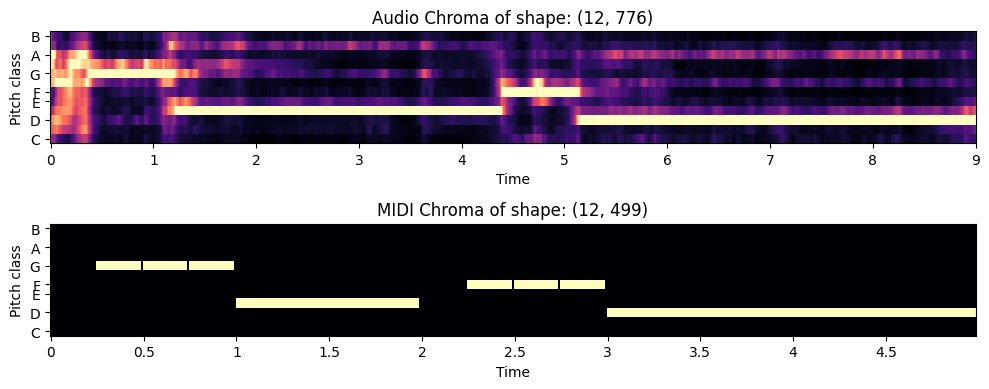

In [1]:
import torch
import numpy as np
import librosa, pretty_midi
import matplotlib.pyplot as plt
from IPython.display import Audio, display

y, sr = librosa.load("assets/MTD1066_Beethoven_Op067-01.wav", sr=None, mono=True)
tuning = librosa.estimate_tuning(y=y, sr=sr)
y_chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=512, tuning=tuning)
y_chroma /= np.max(y_chroma)
display(Audio(y, rate=sr))

midi_data = pretty_midi.PrettyMIDI("assets/MTD1066_Beethoven_Op067-01.mid")
midi_chroma = midi_data.get_chroma(fs=100)
midi_chroma[midi_chroma > 0] = 1.0

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.title(f"Audio Chroma of shape: {y_chroma.shape}")
librosa.display.specshow(y_chroma, y_axis='chroma', x_axis='time', sr=sr, hop_length=512)
plt.subplot(2, 1, 2)
plt.title(f"MIDI Chroma of shape: {midi_chroma.shape}")
librosa.display.specshow(midi_chroma, y_axis='chroma', x_axis='time', sr=sr, hop_length=sr//100)
plt.tight_layout()
plt.show()



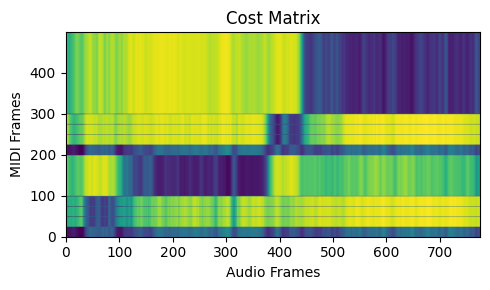

In [2]:
# Cosine similarityに基づく類似度行列を計算

y_chroma_tensor = torch.tensor(y_chroma.T, dtype=torch.float32)
midi_chroma_tensor = torch.tensor(midi_chroma.T, dtype=torch.float32)
cost_matrix = 1.0 - torch.nn.functional.cosine_similarity(
    y_chroma_tensor.unsqueeze(1)+1e-8, midi_chroma_tensor.unsqueeze(0)+1e-8, dim=2
)

plt.figure(figsize=(5, 3))
plt.title("Cost Matrix")
plt.imshow(cost_matrix.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.xlabel("Audio Frames")
plt.ylabel("MIDI Frames")
plt.tight_layout()
plt.show()

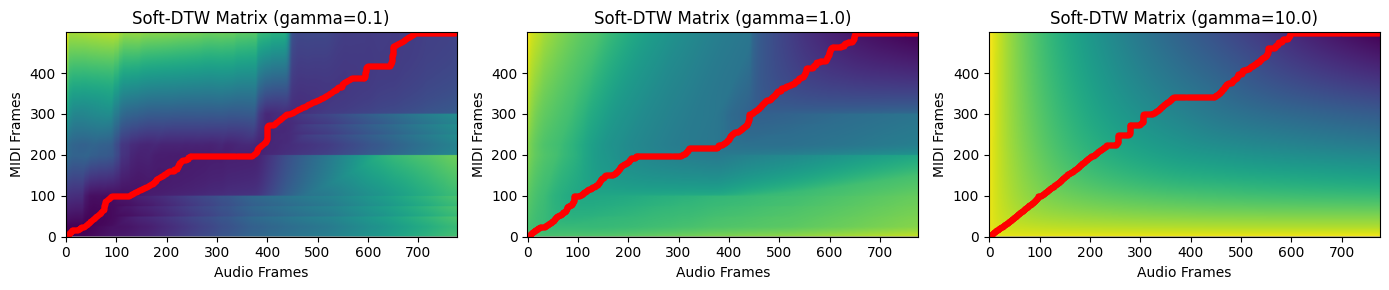

In [3]:
def softmin(x:torch.Tensor, gamma:float = 1.0, dim:int = -1) -> torch.Tensor: 
    return -gamma * torch.logsumexp(-x / gamma, dim=dim)

def naive_softdtw(cost_matrix:torch.Tensor, gamma:float = 1.0) -> torch.Tensor:
    n, m = cost_matrix.shape
    D = torch.full((n + 1, m + 1), float('inf'), device=cost_matrix.device)
    D[0, 0] = 0.0
    warping_path = torch.zeros((m+n, 2), dtype=torch.long, device=cost_matrix.device)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            choices = torch.tensor([D[i - 1, j], D[i, j - 1], D[i - 1, j - 1]], device=cost_matrix.device)
            D[i, j] = cost_matrix[i - 1, j - 1] + softmin(choices, gamma=gamma)

    # 損失関数
    loss = D[n, m]

    # バックトラッキングでワーピングパスを取得
    i, j = n, m
    k = 0
    while i > 0 and j > 0:
        warping_path[k] = torch.tensor([i - 1, j - 1], device=cost_matrix.device)
        k += 1
        choices = torch.tensor([D[i - 1, j], D[i, j - 1], D[i - 1, j - 1]], device=cost_matrix.device)
        argmin = torch.argmin(choices)
        if argmin == 0:
            i -= 1
        elif argmin == 1:
            j -= 1
        else:
            i -= 1
            j -= 1

    return loss, D, warping_path[:k]

# 異なるgamma値でSoft-DTWを計算
softdtw_loss, softdtw_mat, softdtw_wp = naive_softdtw(cost_matrix, gamma=0.1)
softdtw_loss_gamma1, softdtw_mat_gamma1, softdtw_wp_gamma1 = naive_softdtw(cost_matrix, gamma=1.0)
softdtw_loss_gamma10, softdtw_mat_gamma10, softdtw_wp_gamma10 = naive_softdtw(cost_matrix, gamma=10.0)

plt.figure(figsize=(14, 3))
plt.subplot(1, 3, 1)
plt.title("Soft-DTW Matrix (gamma=0.1)")
plt.imshow(softdtw_mat.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.plot(softdtw_wp[:, 0].numpy(), softdtw_wp[:, 1].numpy(), marker='.', color='r')
plt.xlabel("Audio Frames")
plt.ylabel("MIDI Frames")
plt.subplot(1, 3, 2)
plt.title("Soft-DTW Matrix (gamma=1.0)")
plt.imshow(softdtw_mat_gamma1.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.plot(softdtw_wp_gamma1[:, 0].numpy(), softdtw_wp_gamma1[:, 1].numpy(), marker='.', color='r')
plt.xlabel("Audio Frames")
plt.ylabel("MIDI Frames")
plt.subplot(1, 3, 3)
plt.title("Soft-DTW Matrix (gamma=10.0)")
plt.imshow(softdtw_mat_gamma10.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.plot(softdtw_wp_gamma10[:, 0].numpy(), softdtw_wp_gamma10[:, 1].numpy(), marker='.', color='r')
plt.xlabel("Audio Frames")
plt.ylabel("MIDI Frames")
plt.tight_layout()
plt.show()

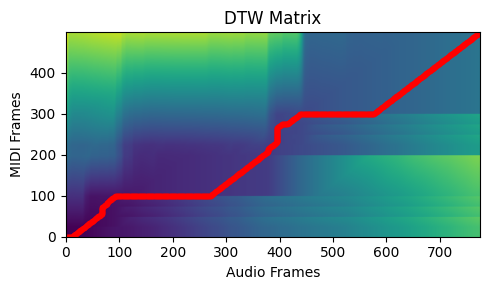

In [4]:
# 通常のDTW
dtw_mat, dtw_wp = librosa.sequence.dtw(X=y_chroma+1e-8, Y=midi_chroma+1e-8, metric='cosine')
plt.figure(figsize=(5, 3))
plt.title("DTW Matrix")
plt.imshow(dtw_mat.T, origin='lower', aspect='auto', cmap='viridis')
plt.xlabel("Audio Frames")
plt.ylabel("MIDI Frames")
plt.plot(dtw_wp[:, 0], dtw_wp[:, 1], marker='.', color='r')
plt.tight_layout()
plt.show()

## オープンソース実装

Soft-DTWの勾配計算はPyTorchの自動微分に任せると極めて非効率なので、明示的に勾配を求めるべきです。上記のナイーブな実装よりも遥かに効率的なオープンソース実装を利用しましょう。

ここではリポジトリ https://github.com/Sleepwalking/pytorch-softdtw.git の実装を利用し、Soft-DTW損失を最小化する例を示します。

Iteration 0, Loss: 9586.216796875
Iteration 100, Loss: 1443.6712646484375
Iteration 200, Loss: -412.21929931640625
Iteration 300, Loss: -838.68798828125
Iteration 400, Loss: -954.2404174804688
Iteration 500, Loss: -988.6029052734375
Iteration 600, Loss: -1002.5380859375
Iteration 700, Loss: -1006.84033203125
Iteration 800, Loss: -1009.3980712890625
Iteration 900, Loss: -1011.64697265625


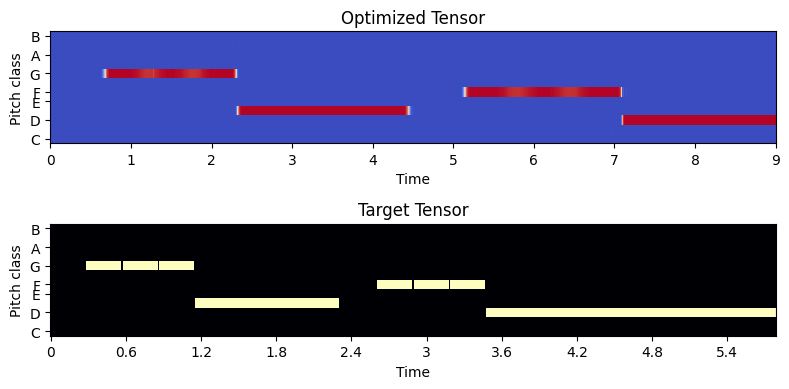

In [5]:
from soft_dtw import SoftDTW
sdtw = SoftDTW(gamma=1, normalize=False)

learning_tensor = torch.randn_like(y_chroma_tensor)
learning_tensor.requires_grad_()
target_tensor = midi_chroma_tensor

optimizer = torch.optim.Adam([learning_tensor], lr=0.01)

for i in range(1000):
    optimizer.zero_grad()
    loss = sdtw.forward(learning_tensor.unsqueeze(0), target_tensor.unsqueeze(0))
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")

plt.figure(figsize=(8,4))
plt.subplot(2,1,1)
librosa.display.specshow(learning_tensor.T.detach().cpu().numpy(), y_axis='chroma', x_axis='time', sr=sr, hop_length=512, cmap='coolwarm')
plt.title("Optimized Tensor")
plt.subplot(2,1,2)
librosa.display.specshow(target_tensor.T.detach().cpu().numpy(), y_axis='chroma', x_axis='time', sr=sr, hop_length=512)
plt.title("Target Tensor")
plt.tight_layout()
plt.show()
